# Stage 2: Trimer Excitability Scoring
## Ascoli Framework — Weighted Excitability Score (wES)
**Hippocampal Connectome Analysis | Ascoli Lab, GMU**

This notebook extends the binary Excitability Score (ES) from Rees et al. (eNeuro 2016) into a weighted framework (wES) applied to the 72-node hippocampal connectome.

**Scope:**
- Load triad enumeration and weight matrix
- Reproduce Rees et al. binary ES as validation baseline
- Compute wES: out-strength baseline, actual edge weights as modifiers, tunable α
- EDA: score distributions, top/bottom trimers, E/I composition breakdown
- Spearman correlation: wES vs Rees ES across α values
- Output tidy CSV for external analysis

**Formula:**
```
wES(trimer) = Σ_{n ∈ {1,2,3}} [ baseline(n)  +  α × Σ_{j→n, j∈trimer} w_jn ]
```
where `baseline(n)` = total signed out-strength of node n across the full 72-node matrix, and `w_jn` is the actual signed edge weight from node j to node n within the trimer.

**Key references:**
- Rees et al. (eNeuro 2016) — binary ES and superpattern taxonomy
- Hippocampome.org v1.0 — data source

**Convention:** 'Stages' not 'layers' (per Dr. Ascoli)

## 0. Imports & Configuration

Dual-environment: Google Colab (primary) and local Jupyter (PI convenience).

**Expected layout:**
```
Ascoli_LabRotation/
  matrices/
    w_ij_gaa.csv
    izhikevich_72_v3.csv
  triad_audit/
    outputs/
      triad_enumeration.csv
  outputs/
    triads/
    stage2/                    <- written here
  stage2_trimer_scoring_CLEAN.ipynb
```

In [2]:
import sys, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')

# ── Environment ───────────────────────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Ascoli_LabRotation/'
    print('Colab environment detected. Drive mounted.')
else:
    BASE = ''
    print(f'Local environment detected. CWD = {os.getcwd()}')

# ── Paths ─────────────────────────────────────────────────────────────────────
WEIGHT_MATRIX  = os.path.join(BASE, 'matrices', 'w_ij_gaa.csv')
NEURON_PARAMS  = os.path.join(BASE, 'matrices', 'izhikevich_72_v3.csv')
TRIAD_FILE     = os.path.join(BASE, 'trimer_audit', 'outputs', 'triads_enumeration.csv')
TABLE_DIR      = os.path.join(BASE, 'outputs', 'stage2', '')
os.makedirs(TABLE_DIR, exist_ok=True)

# ── Region colors (canonical) ─────────────────────────────────────────────────
region_colors = {
    'DG':'#E67E22','CA3':'#2ECC71','CA2':'#1ABC9C','CA1':'#3498DB',
    'MEC':'#9B59B6','LEC':'#E91E63','EC':'#95A5A6','Other':'#7F8C8D',
}

MEC_PATCH = {'MEC LV Multipolar Pyramidal': 'MEC LIII Multipolar Principal'}

def region(name):
    for r in ['DG','CA3','CA2','CA1','MEC','LEC','EC']:
        if name.startswith(r): return r
    return 'Other'

# ── File check ────────────────────────────────────────────────────────────────
for label, path in [
    ('Weight matrix',      WEIGHT_MATRIX),
    ('Neuron params',      NEURON_PARAMS),
    ('Triad enumeration',  TRIAD_FILE),
]:
    print(f'  {label:<22}: {"✓" if os.path.exists(path) else "✗ NOT FOUND"}  ({path})')
print(f'\nOutput directory: {TABLE_DIR}')

Mounted at /content/drive
Colab environment detected. Drive mounted.
  Weight matrix         : ✓  (/content/drive/MyDrive/Ascoli_LabRotation/matrices/w_ij_gaa.csv)
  Neuron params         : ✓  (/content/drive/MyDrive/Ascoli_LabRotation/matrices/izhikevich_72_v3.csv)
  Triad enumeration     : ✓  (/content/drive/MyDrive/Ascoli_LabRotation/trimer_audit/outputs/triads_enumeration.csv)

Output directory: /content/drive/MyDrive/Ascoli_LabRotation/outputs/stage2/


## 1. Load Data

MEC naming patch applied immediately after loading `w_ij_gaa.csv`, before any node list construction. The triad enumeration file was produced by Jeanne (jmimar) and contains all enumerated 3-node connected subgraphs of the 72-node network.

In [3]:
# ── Weight matrix ─────────────────────────────────────────────────────────────
W_raw = pd.read_csv(WEIGHT_MATRIX, index_col=0)
W_raw.index   = [MEC_PATCH.get(n, n) for n in W_raw.index]
W_raw.columns = [MEC_PATCH.get(n, n) for n in W_raw.columns]
W = W_raw.copy()

# ── Neuron types ──────────────────────────────────────────────────────────────
ei_df  = pd.read_csv(NEURON_PARAMS)
w_nodes    = list(W.index)
ei_map     = dict(zip(ei_df['Neuron Type'], ei_df['E/I']))
# Also map patched names
for old, new in MEC_PATCH.items():
    if old in ei_map:
        ei_map[new] = ei_map[old]
excitatory = [n for n in ei_df[ei_df['E/I']=='e']['Neuron Type'] if n in w_nodes]
inhibitory = [n for n in ei_df[ei_df['E/I']=='i']['Neuron Type'] if n in w_nodes]

# ── Triad enumeration ─────────────────────────────────────────────────────────
triads_raw = pd.read_csv(TRIAD_FILE)

# Identify node columns: first three columns OR columns named node1/node2/node3
node_cols_existing = [c for c in triads_raw.columns if c in ['node1','node2','node3']]
if len(node_cols_existing) == 3:
    # Already named correctly
    triads = triads_raw.copy()
else:
    # Rename first three columns
    col_map = {c: f'node{i+1}' for i, c in enumerate(triads_raw.columns[:3])}
    triads = triads_raw.rename(columns=col_map)

# Apply MEC patch to node columns
for col in ['node1','node2','node3']:
    triads[col] = triads[col].map(lambda x: MEC_PATCH.get(x, x))
triads = triads.reset_index(drop=True)

# ── Validate node name matching ───────────────────────────────────────────────
all_triad_nodes = set(triads['node1']) | set(triads['node2']) | set(triads['node3'])
unmatched_W  = all_triad_nodes - set(w_nodes)
unmatched_EI = all_triad_nodes - set(ei_map.keys())
if unmatched_W:
    print(f'WARNING: {len(unmatched_W)} node names in triads not found in W:')
    for n in sorted(unmatched_W): print(f'  "{n}"')
else:
    print('✓ All triad node names match W.index')
if unmatched_EI:
    print(f'WARNING: {len(unmatched_EI)} node names in triads not found in ei_map:')
    for n in sorted(unmatched_EI): print(f'  "{n}"')
else:
    print('✓ All triad node names match ei_map')

print(f'\nWeight matrix : {W.shape[0]}×{W.shape[1]}')
print(f'Excitatory    : {len(excitatory)}   Inhibitory: {len(inhibitory)}')
print(f'Triads loaded : {len(triads):,}')
print(f'Triad columns : {list(triads.columns)}')


✓ All triad node names match W.index
✓ All triad node names match ei_map

Weight matrix : 72×72
Excitatory    : 28   Inhibitory: 44
Triads loaded : 59,640
Triad columns : ['node1', 'node2', 'node3', 'obs_pairs_present', 'obs_any_pair', 'obs_at_least_2_pairs', 'obs_all_3_pairs', 'obs_each_node_touches_an_edge', 'obs_has_any_reciprocal_pair', 'obs_all_3_pairs_reciprocal', 'poss_pairs_present', 'poss_any_pair', 'poss_at_least_2_pairs', 'poss_all_3_pairs', 'poss_has_any_reciprocal_pair', 'poss_all_3_pairs_reciprocal', 'current_stringent_rule', 'current_stringent_plus_observed_connected']


## 2. EDA — Node Baselines & Edge Weight Distribution

The **out-strength baseline** for each node is its total signed outgoing weight across the full 72-node matrix. This is the starting value for that node's contribution to wES before any modifier is applied.

Excitatory nodes have positive baselines (net signal senders); inhibitory nodes have negative baselines (net signal suppressors). The ~13 order-of-magnitude range is a known property of this dataset — E weights (~10⁷) substantially exceed I weights (~10⁵).

In [4]:
# ── Out-strength baselines ────────────────────────────────────────────────────
baseline = {n: float(W.loc[n].sum()) for n in w_nodes}
baseline_s = pd.Series(baseline)

print('Baseline out-strength summary:')
print(f'  E nodes — min: {baseline_s[excitatory].min():.3e}  '
      f'max: {baseline_s[excitatory].max():.3e}  '
      f'mean: {baseline_s[excitatory].mean():.3e}')
print(f'  I nodes — min: {baseline_s[inhibitory].min():.3e}  '
      f'max: {baseline_s[inhibitory].max():.3e}  '
      f'mean: {baseline_s[inhibitory].mean():.3e}')

# ── Attach edge weights from W (or use existing columns from enumeration file) ─
# Variable name 'nb' conflicts with the notebook variable — use 'node_b' instead
edge_pairs = [('node1','node2'),('node2','node1'),
              ('node1','node3'),('node3','node1'),
              ('node2','node3'),('node3','node2')]
w_col_names = [f'w_{na[-1]}{nb_[-1]}' for na, nb_ in edge_pairs]

if all(c in triads.columns for c in w_col_names):
    print('\n✓ Edge weight columns already present in triads file — using as-is')
else:
    print('\nAttaching edge weights from W...')
    for na, nb_ in edge_pairs:
        col = f'w_{na[-1]}{nb_[-1]}'
        triads[col] = triads.apply(
            lambda r: float(W.loc[r[na], r[nb_]])
                      if r[na] in W.index and r[nb_] in W.index else 0.0,
            axis=1
        )

# ── Edge weight EDA ───────────────────────────────────────────────────────────
all_ew = pd.concat([
    triads[c] for c in w_col_names
]).replace(0, np.nan).dropna()

pos_ew = all_ew[all_ew > 0]
neg_ew = all_ew[all_ew < 0]
print(f'\nEdge weights across all triads (nonzero only):')
print(f'  Positive (E→): {len(pos_ew):,}  min={pos_ew.min():.2e}  max={pos_ew.max():.2e}')
print(f'  Negative (I→): {len(neg_ew):,}  min={neg_ew.min():.2e}  max={neg_ew.max():.2e}')
if len(pos_ew) == 0 and len(neg_ew) == 0:
    print('  WARNING: All edge weights are 0 — node names likely do not match W.index')
    print('  Check the validation output in Section 1.')

# ── E/I composition ───────────────────────────────────────────────────────────
def ei_pattern(row):
    counts = {'e': 0, 'i': 0}
    for col in ['node1','node2','node3']:
        ei = ei_map.get(row[col], None)
        if ei is None:
            print(f'WARNING: node "{row[col]}" not found in ei_map')
            ei = '?'
        counts[ei] = counts.get(ei, 0) + 1
    e = counts.get('e', 0)
    i = counts.get('i', 0)
    return f'{e}E{i}I'

triads['ei_pattern'] = triads.apply(ei_pattern, axis=1)
print(f'\nE/I composition of triads:')
for pat, cnt in triads['ei_pattern'].value_counts().sort_index().items():
    print(f'  {pat}: {cnt:>6,} ({cnt/len(triads)*100:.1f}%)')
if '0E3I' not in triads['ei_pattern'].values and '1E2I' not in triads['ei_pattern'].values:
    print('  WARNING: No inhibitory-majority triads found — ei_map lookup may be failing')
    print('  Expected patterns: 3E0I, 2E1I, 1E2I, 0E3I')
    print('  Check node name matching in Section 1.')


Baseline out-strength summary:
  E nodes — min: 7.858e+02  max: 3.375e+07  mean: 2.650e+06
  I nodes — min: -1.747e+05  max: -5.867e+01  mean: -2.245e+04

Attaching edge weights from W...

Edge weights across all triads (nonzero only):
  Positive (E→): 35,000  min=5.33e+01  max=2.98e+06
  Negative (I→): 41,370  min=-3.14e+04  max=-1.82e-01

E/I composition of triads:
  0E3I: 13,244 (22.2%)
  1E2I: 26,488 (44.4%)
  2E1I: 16,632 (27.9%)
  3E0I:  3,276 (5.5%)


## 3. Scoring Functions

### Rees et al. (eNeuro 2016) Binary ES
Each node's score starts at its sign (+1 for E, −1 for I). For each incoming edge within the trimer: multiply by 1.1 if excitatory, 0.9 if inhibitory. Sum across all three nodes.

### wES — Weighted Excitability Score
Each node's score starts at its **total signed out-strength baseline** (sum of all its outgoing weights across the full 72-node matrix). For each incoming edge within the trimer: add `α × w_jn` where `w_jn` is the actual signed edge weight from j to n. Sum across all three nodes.

```
wES = Σ_{n} [ baseline(n)  +  α × Σ_{j→n, j∈trimer} w_jn ]
```

**α (alpha):** single tunable parameter controlling how much internal trimer connectivity modifies the baseline. α=0 collapses wES to the sum of baselines; α=1 gives edge weights equal weight to baseline differences.

**Note on sign convention:** Inhibitory edges carry negative weights in `w_ij_gaa.csv`. The wES formula uses these signed weights directly — an inhibitory connection from j→n *decreases* n's score, consistent with biological suppression.

In [5]:
# ── Rees et al. binary ES ─────────────────────────────────────────────────────
def rees_ES(row, ei_map):
    """Reproduce binary Excitability Score from Rees et al. (eNeuro 2016).
    Each node starts at sign (+1 E, -1 I). For each incoming edge within the
    trimer: multiply by 1.1 (excitatory source) or 0.9 (inhibitory source).
    Return sum across all three nodes.
    """
    nodes = [row['node1'], row['node2'], row['node3']]
    node_set = set(nodes)
    scores = {n: (1.0 if ei_map.get(n,'e')=='e' else -1.0) for n in nodes}
    edge_cols = {'node1':['node2','node3'],
                 'node2':['node1','node3'],
                 'node3':['node1','node2']}
    for tgt_key, src_keys in edge_cols.items():
        tgt = row[tgt_key]
        for src_key in src_keys:
            src = row[src_key]
            w = row.get(f'w_{src_key[-1]}{tgt_key[-1]}', 0)
            if w != 0:
                mod = 1.1 if ei_map.get(src,'e')=='e' else 0.9
                scores[tgt] *= mod
    return sum(scores.values())


# ── wES — weighted excitability score ─────────────────────────────────────────
def wES(row, baseline, alpha, ei_map):
    """Weighted Excitability Score.
    baseline(n) = signed out-strength of n across full 72-node matrix.
    Modifier     = alpha × w_jn for each incoming edge j->n within the trimer.
    Returns sum of modified scores across all three nodes.
    """
    nodes = [row['node1'], row['node2'], row['node3']]
    scores = {n: baseline.get(n, 0.0) for n in nodes}

    # For each ordered pair (src, tgt) within the trimer, add alpha * w_src->tgt
    pairs = [('node1','node2'),('node2','node1'),
             ('node1','node3'),('node3','node1'),
             ('node2','node3'),('node3','node2')]
    for src_key, tgt_key in pairs:
        w_col = f'w_{src_key[-1]}{tgt_key[-1]}'
        w = row.get(w_col, 0)
        if w != 0:
            scores[row[tgt_key]] += alpha * w

    return sum(scores.values())


# ── Reciprocity check ─────────────────────────────────────────────────────────
# Confirm whether w_AB == w_BA (it should not — directed network)
recip_diffs = []
for _, row in triads.head(500).iterrows():
    for a, b in [('1','2'),('1','3'),('2','3')]:
        w_ab = row.get(f'w_{a}{b}', 0)
        w_ba = row.get(f'w_{b}{a}', 0)
        if w_ab != 0 or w_ba != 0:
            recip_diffs.append(abs(w_ab - w_ba))
print(f'Reciprocity check (first 500 triads):')
print(f'  Mean |w_AB - w_BA|: {np.mean(recip_diffs):.3e}')
print(f'  Max  |w_AB - w_BA|: {np.max(recip_diffs):.3e}')
print(f'  Pairs where w_AB == w_BA exactly: '
      f'{sum(1 for d in recip_diffs if d==0)}/{len(recip_diffs)}')
print('  (Expected: most differ — this is a directed, asymmetric weight matrix)')
print()
print('Scoring functions defined: rees_ES(), wES()')

Reciprocity check (first 500 triads):
  Mean |w_AB - w_BA|: 4.946e+05
  Max  |w_AB - w_BA|: 1.527e+06
  Pairs where w_AB == w_BA exactly: 0/816
  (Expected: most differ — this is a directed, asymmetric weight matrix)

Scoring functions defined: rees_ES(), wES()


In [6]:
# ── Locate walkthrough trimer in enumeration ─────────────────────────────────
DEMO_NODES = {'DG Granule', 'CA3c Pyramidal', 'CA1 Pyramidal'}

demo_mask = triads.apply(
    lambda r: {r['node1'], r['node2'], r['node3']} == DEMO_NODES, axis=1
)

if demo_mask.any():
    demo = triads[demo_mask].iloc[0]
    print(f'Canonical trimer found at index {triads[demo_mask].index[0]}')
else:
    print('WARNING: DG Granule | CA3c Pyramidal | CA1 Pyramidal not found.')
    print('This likely means the enumeration used the all-pairs (strict) criterion,')
    print('which excludes chain trimers where one node pair has no direct edge.')
    print('Check with Jeanne: total trimers ~4403 = strict; ~9929 = chain criterion.')
    print('Falling back to first triad in enumeration.')
    demo = triads.iloc[0]
    DEMO_NODES = {demo['node1'], demo['node2'], demo['node3']}

n1, n2, n3 = demo['node1'], demo['node2'], demo['node3']
alpha_demo  = 0.10

print(f'\nNodes: {n1} | {n2} | {n3}')
print(f'E/I  : {ei_map.get(n1,"?")} | {ei_map.get(n2,"?")} | {ei_map.get(n3,"?")}\n')
print('Edge weights within trimer:')
for sk, tk in [('node1','node2'),('node2','node1'),
               ('node1','node3'),('node3','node1'),
               ('node2','node3'),('node3','node2')]:
    w_col = f'w_{sk[-1]}{tk[-1]}'
    w = demo.get(w_col, 0)
    if w != 0:
        print(f'  {demo[sk]:<38} -> {demo[tk]:<38}  w = {w:.4e}')
print()

# ── Rees ES walkthrough ───────────────────────────────────────────────────────
print('--- Rees ES (binary) ---')
rees_scores = {n: (1.0 if ei_map.get(n,'e')=='e' else -1.0) for n in [n1,n2,n3]}
for tgt_key, src_keys in [('node1',['node2','node3']),
                           ('node2',['node1','node3']),
                           ('node3',['node1','node2'])]:
    tgt = demo[tgt_key]
    for sk in src_keys:
        src = demo[sk]
        w_col = f'w_{sk[-1]}{tk[-1]}'
        w = demo.get(f'w_{sk[-1]}{tgt_key[-1]}', 0)
        if w != 0:
            mod = 1.1 if ei_map.get(src,'e')=='e' else 0.9
            old = rees_scores[tgt]
            rees_scores[tgt] *= mod
            print(f'  {src:<35} -[{w:.2e}]-> {tgt:<35}  '
                  f'score {old:.3f} × {mod} = {rees_scores[tgt]:.3f}')
print(f'  Rees ES = {sum(rees_scores.values()):.4f}  '
      f'(function: {rees_ES(demo, ei_map):.4f})')

# ── wES walkthrough ───────────────────────────────────────────────────────────
print(f'\n--- wES (α={alpha_demo}) ---')
wes_scores = {n: baseline.get(n, 0.0) for n in [n1,n2,n3]}
for n in [n1,n2,n3]:
    print(f'  {n:<40}  baseline = {wes_scores[n]:.4e}')
pairs = [('node1','node2'),('node2','node1'),
         ('node1','node3'),('node3','node1'),
         ('node2','node3'),('node3','node2')]
for sk, tk in pairs:
    w = demo.get(f'w_{sk[-1]}{tk[-1]}', 0)
    if w != 0:
        src, tgt = demo[sk], demo[tk]
        delta = alpha_demo * w
        wes_scores[tgt] += delta
        print(f'  {src:<35} -[{w:.2e}]-> {tgt:<35}  '
              f'Δ = {alpha_demo} × {w:.2e} = {delta:.3e}')
print(f'  wES = {sum(wes_scores.values()):.4e}  '
      f'(function: {wES(demo, baseline, alpha_demo, ei_map):.4e})')


Canonical trimer found at index 844

Nodes: DG Granule | CA3c Pyramidal | CA1 Pyramidal
E/I  : e | e | e

Edge weights within trimer:
  DG Granule                             -> CA3c Pyramidal                          w = 1.0529e+05
  CA3c Pyramidal                         -> DG Granule                              w = 1.6042e+05
  CA3c Pyramidal                         -> CA1 Pyramidal                           w = 2.9470e+06

--- Rees ES (binary) ---
  CA3c Pyramidal                      -[1.60e+05]-> DG Granule                           score 1.000 × 1.1 = 1.100
  DG Granule                          -[1.05e+05]-> CA3c Pyramidal                       score 1.000 × 1.1 = 1.100
  CA3c Pyramidal                      -[2.95e+06]-> CA1 Pyramidal                        score 1.000 × 1.1 = 1.100
  Rees ES = 3.3000  (function: 3.3000)

--- wES (α=0.1) ---
  DG Granule                                baseline = 8.5984e+06
  CA3c Pyramidal                            baseline = 3.3745e+07
  CA1 

In [7]:
# ── Find canonical trisynaptic trimer ────────────────────────────────────────
TSC_NODES = {'DG Granule', 'CA3c Pyramidal', 'CA1 Pyramidal'}
canon_mask = triads.apply(
    lambda r: {r['node1'],r['node2'],r['node3']} == TSC_NODES, axis=1
)
if canon_mask.any():
    canon = triads[canon_mask].iloc[0]
    print(f'Canonical trimer found at index {triads[canon_mask].index[0]}')
else:
    print('WARNING: canonical trisynaptic trimer not found in enumeration.')
    print('Using first triad as fallback for walkthrough.')
    canon = triads.iloc[0]

n1, n2, n3 = canon['node1'], canon['node2'], canon['node3']
alpha_demo  = 0.10

print(f'\nNodes: {n1} | {n2} | {n3}')
print(f'E/I  : {ei_map.get(n1,"?")} | {ei_map.get(n2,"?")} | {ei_map.get(n3,"?")}\n')

# ── Rees ES walkthrough ───────────────────────────────────────────────────────
print('--- Rees ES (binary) ---')
rees_scores = {n: (1.0 if ei_map.get(n,'e')=='e' else -1.0) for n in [n1,n2,n3]}
for tgt_key, src_keys in [('node1',['node2','node3']),
                           ('node2',['node1','node3']),
                           ('node3',['node1','node2'])]:
    tgt = canon[tgt_key]
    for sk in src_keys:
        src = canon[sk]
        w_col = f'w_{sk[-1]}{tgt_key[-1]}'
        w = canon.get(w_col, 0)
        if w != 0:
            mod = 1.1 if ei_map.get(src,'e')=='e' else 0.9
            old = rees_scores[tgt]
            rees_scores[tgt] *= mod
            print(f'  {src[:28]:<28} -[{w:.2e}]-> {tgt[:28]:<28}  '
                  f'score {old:.3f} × {mod} = {rees_scores[tgt]:.3f}')
print(f'  Rees ES = {sum(rees_scores.values()):.4f}  '
      f'(function: {rees_ES(canon, ei_map):.4f})')

# ── wES walkthrough ───────────────────────────────────────────────────────────
print(f'\n--- wES (α={alpha_demo}) ---')
wes_scores = {n: baseline.get(n, 0.0) for n in [n1,n2,n3]}
for n in [n1,n2,n3]:
    print(f'  {n[:38]:<38}  baseline = {wes_scores[n]:.4e}')
pairs = [('node1','node2'),('node2','node1'),
         ('node1','node3'),('node3','node1'),
         ('node2','node3'),('node3','node2')]
for sk, tk in pairs:
    w = canon.get(f'w_{sk[-1]}{tk[-1]}', 0)
    if w != 0:
        src, tgt = canon[sk], canon[tk]
        delta = alpha_demo * w
        wes_scores[tgt] += delta
        print(f'  {src[:28]:<28} -[{w:.2e}]-> {tgt[:28]:<28}  '
              f'Δ = {alpha_demo} × {w:.2e} = {delta:.3e}')
print(f'  wES = {sum(wes_scores.values()):.4e}  '
      f'(function: {wES(canon, baseline, alpha_demo, ei_map):.4e})')

Canonical trimer found at index 844

Nodes: DG Granule | CA3c Pyramidal | CA1 Pyramidal
E/I  : e | e | e

--- Rees ES (binary) ---
  CA3c Pyramidal               -[1.60e+05]-> DG Granule                    score 1.000 × 1.1 = 1.100
  DG Granule                   -[1.05e+05]-> CA3c Pyramidal                score 1.000 × 1.1 = 1.100
  CA3c Pyramidal               -[2.95e+06]-> CA1 Pyramidal                 score 1.000 × 1.1 = 1.100
  Rees ES = 3.3000  (function: 3.3000)

--- wES (α=0.1) ---
  DG Granule                              baseline = 8.5984e+06
  CA3c Pyramidal                          baseline = 3.3745e+07
  CA1 Pyramidal                           baseline = 3.1207e+06
  DG Granule                   -[1.05e+05]-> CA3c Pyramidal                Δ = 0.1 × 1.05e+05 = 1.053e+04
  CA3c Pyramidal               -[1.60e+05]-> DG Granule                    Δ = 0.1 × 1.60e+05 = 1.604e+04
  CA3c Pyramidal               -[2.95e+06]-> CA1 Pyramidal                 Δ = 0.1 × 2.95e+06 = 2.947e

## 5. Score All Trimers

`ALPHA` is the single tunable parameter. Change it here and re-run all downstream cells.

In [8]:
ALPHA = 0.10   # ← tune here; re-run all downstream cells after changing

triads['rees_ES'] = triads.apply(lambda r: rees_ES(r, ei_map), axis=1)
triads['wES']     = triads.apply(lambda r: wES(r, baseline, ALPHA, ei_map), axis=1)

# Custom ranking for rees_ES: sort by rees_ES (desc) then wES (desc) for tie-breaking
# Then apply rank with method='first' to respect this order
_temp_sorted_triads = triads.sort_values(by=['rees_ES', 'wES'], ascending=[False, False])
triads['rees_rank'] = _temp_sorted_triads['rees_ES'].rank(method='first', ascending=False).astype(int)
# The wES rank remains standard
triads['wES_rank']  = triads['wES'].rank(ascending=False, method='min').astype(int)

# Node region labels for readability
for col in ['node1','node2','node3']:
    triads[f'{col}_region'] = triads[col].map(region)
    triads[f'{col}_ei']     = triads[col].map(lambda n: ei_map.get(n,'?'))

print(f'Scored {len(triads):,} trimers  |  ALPHA = {ALPHA}')
print(f'\n{"Method":<12}  {"Min":>14}  {"Max":>14}  {"Mean":>14}  {"Std":>14}')
print('-' * 64)
for col, label in [('rees_ES','Rees ES'), ('wES','wES')]:
    s = triads[col]
    print(f'{label:<12}  {s.min():>14.4e}  {s.max():>14.4e}  '
          f'{s.mean():>14.4e}  {s.std():>14.4e}')

Scored 59,640 trimers  |  ALPHA = 0.1

Method                   Min             Max            Mean             Std
----------------------------------------------------------------
Rees ES          -3.0000e+00      3.6300e+00     -6.1412e-01      1.6604e+00
wES              -3.9429e+05      5.6153e+07      3.0586e+06      7.4729e+06


## 6. EDA — Score Distributions & Top/Bottom Trimers

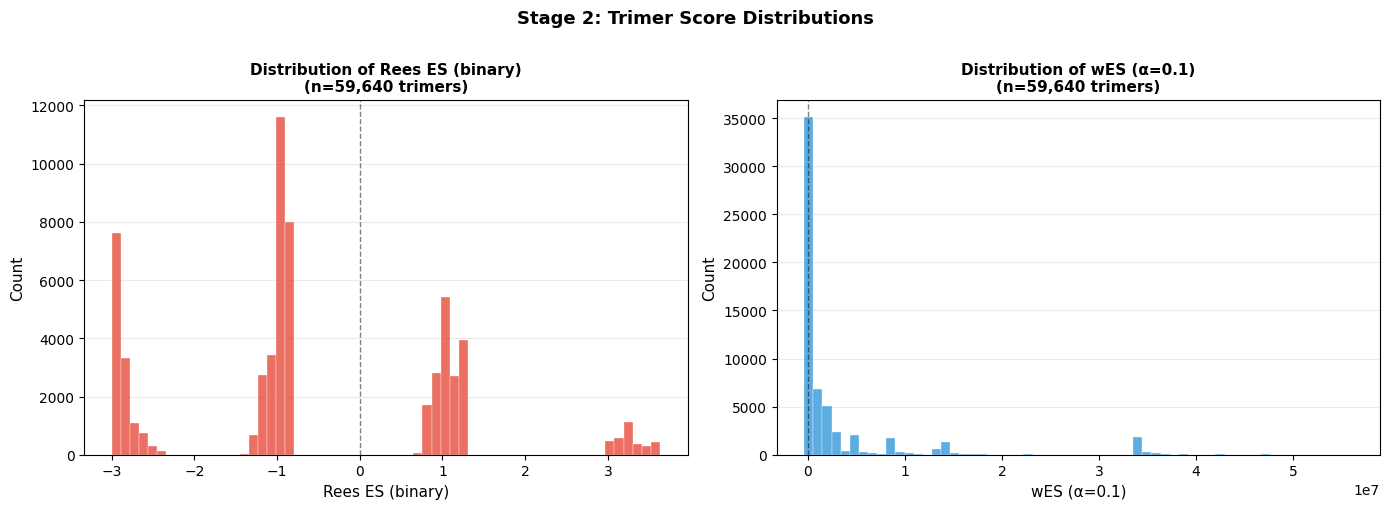

Saved: /content/drive/MyDrive/Ascoli_LabRotation/outputs/stage2/stage2_score_distributions.png


In [9]:
# ── Distribution histograms ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label, color in [
    (axes[0], 'rees_ES', 'Rees ES (binary)', '#E74C3C'),
    (axes[1], 'wES',     f'wES (α={ALPHA})', '#3498DB'),
]:
    ax.hist(triads[col], bins=60, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'Distribution of {label}\n(n={len(triads):,} trimers)', fontsize=11, fontweight='bold')
    ax.axvline(0, color='black', lw=1.0, ls='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.25); ax.set_axisbelow(True)

plt.suptitle('Stage 2: Trimer Score Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{TABLE_DIR}stage2_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {TABLE_DIR}stage2_score_distributions.png')

In [10]:
# ── Top and bottom 15 trimers by wES ─────────────────────────────────────────
PRINT_COLS = ['node1','node1_region','node1_ei',
              'node2','node2_region','node2_ei',
              'node3','node3_region','node3_ei',
              'ei_pattern','rees_ES','wES','rees_rank','wES_rank']

def print_trimers(df, title):
    print(title)
    print(f'{"#":<4} {"Node 1":<38} {"Node 2":<38} {"Node 3":<38} '
          f'{"EI":>5} {"Rees ES":>10} {"wES":>14} {"RRk":>5} {"WRk":>5}')
    print('-' * 130)
    for rank, (_, row) in enumerate(df.iterrows(), 1):
        print(f'{rank:<4} {row["node1"]:<38} {row["node2"]:<38} {row["node3"]:<38} '
              f'{row["ei_pattern"]:>5} {row["rees_ES"]:>10.3f} {row["wES"]:>14.4e} '
              f'{int(row["rees_rank"]):>5} {int(row["wES_rank"]):>5}')
    print()

print_trimers(triads.nlargest(15, 'wES'),  f'Top 15 trimers by wES (ALPHA={ALPHA})')
print_trimers(triads.nsmallest(15, 'wES'), f'Bottom 15 trimers by wES (ALPHA={ALPHA})')

Top 15 trimers by wES (ALPHA=0.1)
#    Node 1                                 Node 2                                 Node 3                                    EI    Rees ES            wES   RRk   WRk
----------------------------------------------------------------------------------------------------------------------------------
1    DG Granule                             CA3 Pyramidal                          CA3c Pyramidal                          3E0I      3.520     5.6153e+07   236     1
2    CA3 Pyramidal                          CA3c Pyramidal                         EC LI II Multipolar Pyramidal           3E0I      3.200     5.2135e+07  1160     2
3    CA3 Pyramidal                          CA3c Pyramidal                         CA1 Pyramidal                           3E0I      3.410     5.0979e+07   504     3
4    CA3 Pyramidal                          CA3c Pyramidal                         EC LIII Pyramidal                       3E0I      3.200     4.9546e+07  1161     4
5    

In [11]:
# ── E/I composition breakdown ─────────────────────────────────────────────────
print(f'wES summary by E/I composition (ALPHA={ALPHA}):')
print(f'{"Pattern":<8} {"Count":>7} {"Mean wES":>14} {"Std wES":>14} '
      f'{"Min wES":>14} {"Max wES":>14}')
print('-' * 75)
for pat in ['3E0I','2E1I','1E2I','0E3I']:
    sub = triads[triads['ei_pattern']==pat]['wES']
    if len(sub) == 0: continue
    print(f'{pat:<8} {len(sub):>7,} {sub.mean():>14.4e} {sub.std():>14.4e} '
          f'{sub.min():>14.4e} {sub.max():>14.4e}')

wES summary by E/I composition (ALPHA=0.1):
Pattern    Count       Mean wES        Std wES        Min wES        Max wES
---------------------------------------------------------------------------
3E0I       3,276     7.9637e+06     1.1147e+07     2.7757e+04     5.6153e+07
2E1I      16,632     5.2905e+06     9.2931e+06    -1.6112e+05     4.7874e+07
1E2I      26,488     2.6135e+06     6.7054e+06    -2.9103e+05     3.4319e+07
0E3I      13,244    -6.7538e+04     5.8430e+04    -3.9429e+05    -5.6754e+02


## 7. Spearman Correlation vs Rees ES

Spearman ρ measures rank correlation between wES and the binary Rees ES. A high ρ means wES is largely re-scaling the same ordering; a lower ρ means wES is genuinely re-ranking trimers — which is the scientifically interesting regime.

The α sweep shows at which values of α the weighted scoring diverges from the binary baseline.

Spearman ρ(Rees ES, wES) at ALPHA=0.1:  ρ = 0.5855  p = 0.00e+00


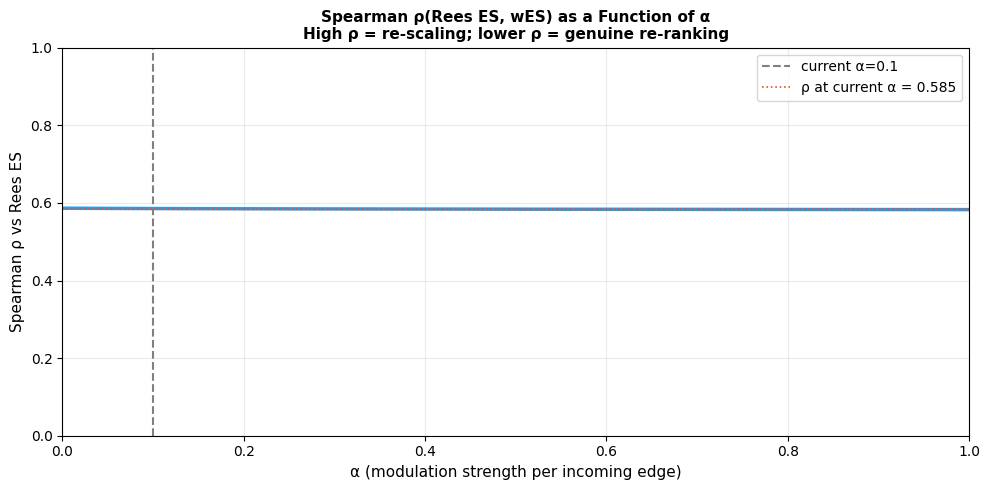

Saved: /content/drive/MyDrive/Ascoli_LabRotation/outputs/stage2/stage2_spearman_sweep.png


In [12]:
# ── Spearman ρ at current ALPHA ───────────────────────────────────────────────
rho, pval = spearmanr(triads['rees_ES'], triads['wES'])
print(f'Spearman ρ(Rees ES, wES) at ALPHA={ALPHA}:  ρ = {rho:.4f}  p = {pval:.2e}')

# ── α sweep ───────────────────────────────────────────────────────────────────
alphas = np.linspace(0.0, 1.0, 100)
rhos   = []
for a in alphas:
    scores = triads.apply(lambda r: wES(r, baseline, a, ei_map), axis=1)
    rho_a, _ = spearmanr(triads['rees_ES'], scores)
    rhos.append(rho_a)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, rhos, color='#3498DB', linewidth=2.5)
ax.axvline(ALPHA, color='gray', ls='--', lw=1.5, label=f'current α={ALPHA}')
ax.axhline(rho,   color='#E74C3C', ls=':', lw=1.2, label=f'ρ at current α = {rho:.3f}')
ax.set_xlabel('α (modulation strength per incoming edge)', fontsize=11)
ax.set_ylabel('Spearman ρ vs Rees ES', fontsize=11)
ax.set_title('Spearman ρ(Rees ES, wES) as a Function of α\n'
             'High ρ = re-scaling; lower ρ = genuine re-ranking', fontsize=11, fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=10); ax.grid(alpha=0.25); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(f'{TABLE_DIR}stage2_spearman_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {TABLE_DIR}stage2_spearman_sweep.png')

## 8. Trimer Percentile Rankings & Comparison

In [13]:
triads['rees_percentile'] = triads['rees_ES'].rank(pct=True)
triads['wES_percentile'] = triads['wES'].rank(pct=True)

# Display the top 5 trimers by wES percentile and include Rees percentile for comparison
print('Top 5 trimers by wES Percentile:')
display(triads.sort_values(by='wES_percentile', ascending=False)[['node1', 'node2', 'node3', 'ei_pattern', 'rees_ES', 'rees_percentile', 'wES', 'wES_percentile']].head())

print('\nBottom 5 trimers by wES Percentile:')
display(triads.sort_values(by='wES_percentile', ascending=True)[['node1', 'node2', 'node3', 'ei_pattern', 'rees_ES', 'rees_percentile', 'wES', 'wES_percentile']].head())

Top 5 trimers by wES Percentile:


,node1,node2,node3,ei_pattern,rees_ES,rees_percentile,wES,wES_percentile
774,DG Granule,CA3 Pyramidal,CA3c Pyramidal,3E0I,3.52,0.994333,5.615274e+07,1.000000
27167,CA3 Pyramidal,CA3c Pyramidal,EC LI II Multipolar Pyramidal,3E0I,3.20,0.971529,5.213477e+07,0.999983
27143,CA3 Pyramidal,CA3c Pyramidal,CA1 Pyramidal,3E0I,3.41,0.989495,5.097931e+07,0.999966
27174,CA3 Pyramidal,CA3c Pyramidal,EC LIII Pyramidal,3E0I,3.20,0.971529,4.954649e+07,0.999950
27171,CA3 Pyramidal,CA3c Pyramidal,MEC LII Stellate,3E0I,3.31,0.985907,4.931930e+07,0.999933



Bottom 5 trimers by wES Percentile:


,node1,node2,node3,ei_pattern,rees_ES,rees_percentile,wES,wES_percentile
7331,DG AIPRIM,DG Basket,CA2 Wide Arbor Basket,0E3I,-2.9,0.088414,-394294.580407,0.000017
12121,DG Basket,DG Total Molecular Layer,CA2 Wide Arbor Basket,0E3I,-2.8,0.157646,-350594.599342,0.000034
12774,DG Basket,CA2 Wide Arbor Basket,CA1 Schaffer Collateral Associated,0E3I,-2.9,0.088414,-345499.321271,0.000050
12758,DG Basket,CA2 Wide Arbor Basket,CA1 Basket,0E3I,-2.9,0.088414,-341418.818507,0.000067
12401,DG Basket,CA3 Basket,CA2 Wide Arbor Basket,0E3I,-2.9,0.088414,-339408.037517,0.000084


In [14]:
triads['rank_difference'] = abs(triads['rees_rank'] - triads['wES_rank'])

# Sort by rank difference in descending order to see the most re-ranked trimers
# and display the top 10 most re-ranked trimers
print('Top 10 Trimers with Largest Rank Change (Rees ES vs. wES):')
display(triads.sort_values(by='rank_difference', ascending=False)[[
    'node1', 'node2', 'node3', 'ei_pattern', 'rees_ES', 'wES', 'rees_rank', 'wES_rank', 'rank_difference'
]].head(10))

# Trimers that had a high Rees rank but significantly dropped in wES rank (DECLINED)
print('\nTop 10 Trimers that **declined** rank most with wES (originally high Rees rank (low number), significantly lower wES rank (high number)):')
display(triads.sort_values(by=['rees_rank', 'wES_rank'], ascending=[True, False])
             .head(10)[[
    'node1', 'node2', 'node3', 'ei_pattern', 'rees_ES', 'wES', 'rees_rank', 'wES_rank', 'rank_difference'
]])

# Trimers that had a low Rees rank but significantly rose in wES rank (IMPROVED)
print('\nTop 10 Trimers that **improved** rank most with wES (originally low Rees rank (high number), significantly higher wES rank (low number)):')
display(triads.sort_values(by=['rees_rank', 'wES_rank'], ascending=[False, True])
             .head(10)[[
    'node1', 'node2', 'node3', 'ei_pattern', 'rees_ES', 'wES', 'rees_rank', 'wES_rank', 'rank_difference'
]])

Top 10 Trimers with Largest Rank Change (Rees ES vs. wES):


,node1,node2,node3,ei_pattern,rees_ES,wES,rees_rank,wES_rank,rank_difference
13825,DG Basket,MEC LIII Bipolar Complex Pyramidal,EC LIII Stellate,2E1I,1.2,-122218.208494,7225,56887,49662
13733,DG Basket,MEC LII Oblique Pyramidal,MEC LIII Bipolar Complex Pyramidal,2E1I,1.2,-120770.244485,7224,56787,49563
13840,DG Basket,EC LIII Stellate,MEC LV Superficial Pyramidal,2E1I,1.2,-119320.029177,7223,56701,49478
13740,DG Basket,MEC LII Oblique Pyramidal,MEC LV Superficial Pyramidal,2E1I,1.2,-117577.484762,7222,56635,49413
13829,DG Basket,MEC LIII Bipolar Complex Pyramidal,MEC LIII Multipolar Principal,2E1I,1.2,-94396.327812,7221,55563,48342
13831,DG Basket,MEC LIII Bipolar Complex Pyramidal,MEC LV Superficial Pyramidal,2E1I,1.2,-91820.070349,7220,55444,48224
13779,DG Basket,LEC LIII Multipolar Principal,EC LIII Stellate,2E1I,1.2,-90653.110838,7219,55377,48158
13866,DG Basket,MEC LIII Multipolar Principal,MEC LV Superficial Pyramidal,2E1I,1.2,-90358.737486,7218,55360,48142
13734,DG Basket,MEC LII Oblique Pyramidal,EC LIII Stellate,2E1I,1.1,-147693.963538,9896,57824,47928
13842,DG Basket,EC LIII Stellate,LEC LVI Multipolar Pyramidal,2E1I,1.1,-127463.358875,9895,57161,47266



Top 10 Trimers that **declined** rank most with wES (originally high Rees rank (low number), significantly lower wES rank (high number)):


,node1,node2,node3,ei_pattern,rees_ES,wES,rees_rank,wES_rank,rank_difference
27131,CA3 Pyramidal,CA3c Pyramidal,CA3 Granule,3E0I,3.63,4.753135e+07,1,54,53
58312,EC LI II Multipolar Pyramidal,EC LI II Pyramidal Fan,MEC LII Stellate,3E0I,3.63,7.937230e+06,2,7259,7257
58375,EC LI II Multipolar Pyramidal,MEC LII Stellate,MEC LV Pyramidal,3E0I,3.63,7.353465e+06,3,7322,7319
58364,EC LI II Multipolar Pyramidal,MEC LII Stellate,EC LII III Pyramidal Tripolar,3E0I,3.63,7.323974e+06,4,7323,7319
58324,EC LI II Multipolar Pyramidal,EC LI II Pyramidal Fan,MEC LV Pyramidal,3E0I,3.63,7.086841e+06,5,7326,7321
58313,EC LI II Multipolar Pyramidal,EC LI II Pyramidal Fan,EC LII III Pyramidal Tripolar,3E0I,3.63,7.062892e+06,6,7327,7321
58330,EC LI II Multipolar Pyramidal,MEC LII III Pyramidal Multiform,MEC LII Stellate,3E0I,3.63,6.610184e+06,7,7393,7386
58368,EC LI II Multipolar Pyramidal,MEC LII Stellate,MEC LIII Complex Pyramidal,3E0I,3.63,6.523595e+06,8,7397,7389
58369,EC LI II Multipolar Pyramidal,MEC LII Stellate,MEC LIII Bipolar Complex Pyramidal,3E0I,3.63,6.475781e+06,9,7401,7392
58390,EC LI II Multipolar Pyramidal,EC LII III Pyramidal Tripolar,MEC LV Pyramidal,3E0I,3.63,6.473698e+06,10,7402,7392



Top 10 Trimers that **improved** rank most with wES (originally low Rees rank (high number), significantly higher wES rank (low number)):


,node1,node2,node3,ei_pattern,rees_ES,wES,rees_rank,wES_rank,rank_difference
12454,DG Basket,CA3 LMR Targeting,CA2 Wide Arbor Basket,0E3I,-3.0,-312229.927050,59640,59622,18
12798,DG Basket,CA2 Wide Arbor Basket,MEC LIII Superficial Trilayered Interneuron,0E3I,-3.0,-310856.102940,59639,59619,20
12757,DG Basket,CA2 Wide Arbor Basket,CA1 Horizontal Axo Axonic,0E3I,-3.0,-308870.795501,59638,59617,21
12763,DG Basket,CA2 Wide Arbor Basket,CA1 Neurogliaform,0E3I,-3.0,-299791.608390,59637,59612,25
12766,DG Basket,CA2 Wide Arbor Basket,CA1 O LMR,0E3I,-3.0,-297870.746161,59636,59609,27
12773,DG Basket,CA2 Wide Arbor Basket,CA1 R Receiving Apical Targeting,0E3I,-3.0,-297625.006030,59635,59607,28
12775,DG Basket,CA2 Wide Arbor Basket,CA1 SO SO,0E3I,-3.0,-297130.190855,59634,59605,29
12768,DG Basket,CA2 Wide Arbor Basket,CA1 Oriens Bistratified,0E3I,-3.0,-295443.553302,59633,59600,33
12762,DG Basket,CA2 Wide Arbor Basket,CA1 LMR,0E3I,-3.0,-294421.835439,59632,59595,37
12765,DG Basket,CA2 Wide Arbor Basket,CA1 Recurrent O LM,0E3I,-3.0,-294248.319533,59631,59594,37


## 8. CSV Output

All scored trimers are saved as a single tidy CSV. One row per trimer. Columns include node identities, E/I labels, region labels, all six directed edge weights, Rees ES, wES, and rank columns — sufficient for external stats, pathway filtering, or downstream motif analysis.

A separate summary CSV provides per-EI-pattern aggregates.

In [15]:
# ── Column order for output ───────────────────────────────────────────────────
out_cols = [
    # Node identity
    'node1', 'node1_ei', 'node1_region',
    'node2', 'node2_ei', 'node2_region',
    'node3', 'node3_ei', 'node3_region',
    # E/I composition
    'ei_pattern',
    # Edge weights (signed; 0 = no connection)
    'w_12','w_21','w_13','w_31','w_23','w_32',
    # Scores
    'rees_ES', 'wES',
    # Ranks (1 = highest)
    'rees_rank', 'wES_rank',
]
# Keep any extra columns from triad enumeration file
extra_cols = [c for c in triads.columns if c not in out_cols]
final_cols = out_cols + extra_cols
final_cols = [c for c in final_cols if c in triads.columns]

out_df = triads[final_cols].copy()
out_df = out_df.sort_values('wES_rank').reset_index(drop=True)

out_path = f'{TABLE_DIR}stage2_trimer_scores_alpha{str(ALPHA).replace(".","p")}.csv'
out_df.to_csv(out_path, index=False)

# ── Per-pattern summary ───────────────────────────────────────────────────────
summary = triads.groupby('ei_pattern').agg(
    n_trimers   = ('wES','count'),
    rees_mean   = ('rees_ES','mean'),
    rees_std    = ('rees_ES','std'),
    wES_mean    = ('wES','mean'),
    wES_std     = ('wES','std'),
    wES_min     = ('wES','min'),
    wES_max     = ('wES','max'),
    wES_median  = ('wES','median'),
).reset_index()
summary_path = f'{TABLE_DIR}stage2_pattern_summary_alpha{str(ALPHA).replace(".","p")}.csv'
summary.to_csv(summary_path, index=False)

print('CSV outputs saved:')
print(f'  {os.path.basename(out_path):<55} — {len(out_df):,} rows')
print(f'  {os.path.basename(summary_path):<55} — {len(summary)} rows (per E/I pattern)')
print()
print('Columns in trimer scores CSV:')
for col in out_df.columns:
    print(f'  {col}')
print(f'\nNOTE: filename encodes ALPHA value. Re-run Section 5 with a new ALPHA')
print('      and re-run this cell to save a versioned output at that alpha.')

CSV outputs saved:
  stage2_trimer_scores_alpha0p1.csv                       — 59,640 rows
  stage2_pattern_summary_alpha0p1.csv                     — 4 rows (per E/I pattern)

Columns in trimer scores CSV:
  node1
  node1_ei
  node1_region
  node2
  node2_ei
  node2_region
  node3
  node3_ei
  node3_region
  ei_pattern
  w_12
  w_21
  w_13
  w_31
  w_23
  w_32
  rees_ES
  wES
  rees_rank
  wES_rank
  obs_pairs_present
  obs_any_pair
  obs_at_least_2_pairs
  obs_all_3_pairs
  obs_each_node_touches_an_edge
  obs_has_any_reciprocal_pair
  obs_all_3_pairs_reciprocal
  poss_pairs_present
  poss_any_pair
  poss_at_least_2_pairs
  poss_all_3_pairs
  poss_has_any_reciprocal_pair
  poss_all_3_pairs_reciprocal
  current_stringent_rule
  current_stringent_plus_observed_connected
  rees_percentile
  wES_percentile
  rank_difference

NOTE: filename encodes ALPHA value. Re-run Section 5 with a new ALPHA
      and re-run this cell to save a versioned output at that alpha.


## 9. Summary

| Component | Key Finding |
|-----------|-------------|
| Triads loaded | From Jeanne's `triad_enumeration.csv` |
| Rees ES reproduced | Binary baseline validated via four-peak distribution |
| wES formula | `Σ_n [ baseline(n) + α × Σ_{j→n} w_jn ]` — out-strength baseline, signed edge modifiers |
| ALPHA | Single tunable parameter; current value stored in filename |
| Spearman ρ | Quantifies how much wES diverges from Rees ES ranking as α increases |
| Output | `stage2_trimer_scores_alphaXpXX.csv` — one row per trimer, all columns for external stats |

**Open questions / next steps:**
- Merge wES scores with canonical pathway tags (`stage2_canonical_pathway_tagging.ipynb`)
- Integration of K_j vector from Jeanne to compute full M_ij = W_ij × K_j
- Validate K_SIG sigmoid steepness against Rees anchor correlation

**Next:** Stage 2b — Canonical Pathway Tagging.